In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = fetch_california_housing()
dataset

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [3]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)

In [4]:
df['Price'] = dataset.target

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [8]:
X = df.drop(columns='Price')

In [9]:
# VIF requires an intercept/constant column to calculate correctly
X_vif = sm.add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data)

      Feature           VIF
0       const  17082.623698
1      MedInc      2.501295
2    HouseAge      1.241254
3    AveRooms      8.342786
4   AveBedrms      6.994995
5  Population      1.138125
6    AveOccup      1.008324
7    Latitude      9.297624
8   Longitude      8.962263


In [10]:
X = df.drop(columns=['AveBedrms', 'Latitude', 'Price'])

In [11]:
X.head()

,MedInc,HouseAge,AveRooms,Population,AveOccup,Longitude
0,8.3252,41.0,6.984127,322.0,2.555556,-122.23
1,8.3014,21.0,6.238137,2401.0,2.109842,-122.22
2,7.2574,52.0,8.288136,496.0,2.802260,-122.24
3,5.6431,52.0,5.817352,558.0,2.547945,-122.25
4,3.8462,52.0,6.281853,565.0,2.181467,-122.25


In [12]:
# VIF requires an intercept/constant column to calculate correctly
X_vif = sm.add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data)

      Feature          VIF
0       const  3621.092018
1      MedInc     1.126662
2    HouseAge     1.150261
3    AveRooms     1.154354
4  Population     1.125209
5    AveOccup     1.006713
6   Longitude     1.018617


In [13]:
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [14]:
y=df['Price']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
Scaler = StandardScaler()

In [17]:
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [18]:
multi_regressor = LinearRegression()

In [19]:
multi_regressor.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.84, 0.22,-0.06, 0.03,-0.05,-0.02]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.069
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[144.47,136.32,121.21,115.97,101.58, 93.67]"


In [20]:
y_pred = multi_regressor.predict(X_test_scaled)
print(y_pred)

[1.05436842 1.51331115 2.37844644 ... 1.82088177 1.79740953 1.62020784]


In [21]:
print(f"The coefficient are {multi_regressor.coef_}")
print(f"The intercept is {multi_regressor.intercept_}")

The coefficient are [ 0.84262212  0.22163368 -0.05968894  0.03495906 -0.05176935 -0.02373008]
The intercept is 2.0692396089424143


In [22]:
# evaluation metrics

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("="*65)
print("The mean square error is : ", round(mse, 2))
print("The mean absolute error is : ", round(mae, 2))
print("The root mean square error is : ", round(rmse, 2))

r2 = r2_score(y_test, y_pred)
adj_r2 = 1- ((1-r2)*(len(X_test)-1))/(len(X_test) - X_train.shape[1] -1)

print("="*65)
print("The r2 score is : ", round(r2, 2))
print("The adjusted r2 score is : ", round(adj_r2, 2))

The mean square error is :  0.64
The mean absolute error is :  0.59
The root mean square error is :  0.8
The r2 score is :  0.51
The adjusted r2 score is :  0.51


In [23]:
y_train_pred = multi_regressor.predict(X_train_scaled)

print("--- Overfitting vs Underfitting Check ---")
print("Train R2 Score:", round(r2_score(y_train, y_train_pred), 4))
print("Test R2 Score:", round(r2_score(y_test, y_pred), 4))

--- Overfitting vs Underfitting Check ---
Train R2 Score: 0.5148
Test R2 Score: 0.5145


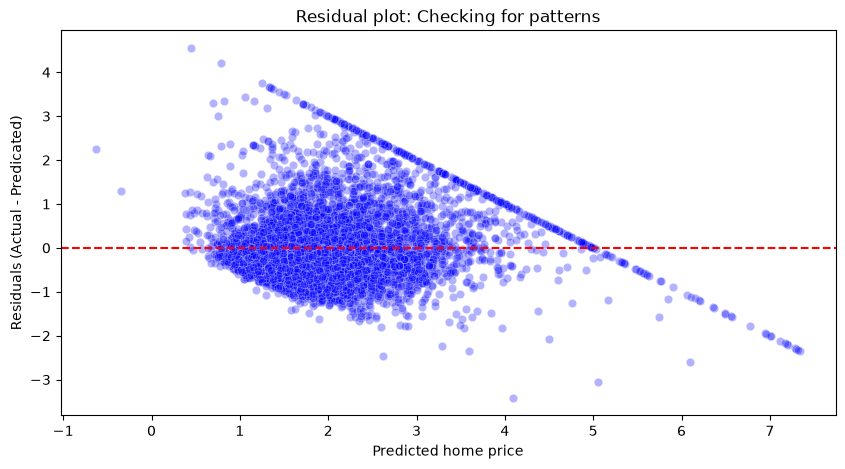

In [24]:
# Residual Analysis (Ploting the errors)



residuals = y_test - y_pred

plt.figure(figsize=(10,5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted home price')
plt.ylabel('Residuals (Actual - Predicated)')
plt.title('Residual plot: Checking for patterns')
plt.show()

In [25]:
import joblib

joblib.dump(Scaler, 'Standard_scaler_multi.joblib')
joblib.dump(multi_regressor, 'mutli_regressor_model.joblib')
print('Files saved sucessfully')

Files saved sucessfully
